In [42]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [44]:
import numpy as np
import pandas as pd

# CSV 파일의 컬럼 이름 지정 (첫 번째 컬럼은 버릴 값이므로 "NaN"으로 명명)
names = ["NaN", "user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis"]

# CSV 파일 읽기 (header 없이, 첫 줄은 skip)
data = pd.read_csv("/Users/ohheungchan/workspace/AI_Study/paperwork/WISDM.csv",
                   header=None, names=names, skiprows=1)

# "NaN" 컬럼 제거
df = data.drop('NaN', axis=1)

# 'z_axis' 컬럼을 문자열로 변환 후 세미콜론(;) 제거
df["z_axis"] = df["z_axis"].astype(str).str.replace(';', '', regex=True)

# 문자열 데이터를 float으로 변환 (에러 발생 시 NaN으로 처리)
df["timestamp"] = pd.to_numeric(df["timestamp"], errors='coerce')
df["x_axis"]    = pd.to_numeric(df["x_axis"], errors='coerce')
df["y_axis"]    = pd.to_numeric(df["y_axis"], errors='coerce')
df["z_axis"]    = pd.to_numeric(df["z_axis"], errors='coerce')

# 결측치가 있는 행 제거
df.dropna(axis=0, how='any', inplace=True)

# 결과 확인
print(df.head())
print("DataFrame shape:", df.shape)

   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164
DataFrame shape: (1098203, 6)


In [45]:
# 타임스탬프를 기준으로 정렬한 후, 각 activity 그룹에서 마지막 24,000개 샘플을 test 셋으로 선택
test_df = data.groupby("activity", group_keys=False).apply(
    lambda x: x.sort_values("timestamp").tail(24000)
)

# test_df에 포함된 인덱스를 제외한 나머지를 train 셋으로 지정
train_df = data.drop(test_df.index)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# 각 그룹별 분포 확인 (타임스탬프 기반으로 분할한 경우에도 각 그룹의 샘플 수는 동일해야 함)
print("Train set activity distribution:")
print(train_df["activity"].value_counts())
print("\nTest set activity distribution:")
print(test_df["activity"].value_counts())

Train set shape: (954203, 7)
Test set shape: (144000, 7)
Train set activity distribution:
activity
Walking       400397
Jogging       318176
Upstairs       98869
Downstairs     76427
Sitting        35939
Standing       24395
Name: count, dtype: int64

Test set activity distribution:
activity
Downstairs    24000
Jogging       24000
Sitting       24000
Standing      24000
Upstairs      24000
Walking       24000
Name: count, dtype: int64


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_33306/3501039775.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = data.groupby("activity", group_keys=False).apply(


Label Mapping: {'Downstairs': 0, 'Jogging': 1, 'Sitting': 2, 'Standing': 3, 'Upstairs': 4, 'Walking': 5}


/Users/ohheungchan/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/ohheungchan/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Walking count: 400397
Sampling Strategy: {0: 400397, 1: 400397, 2: 400397, 3: 400397, 4: 400397}
After SMOTE balancing:
Downstairs: 400397
Jogging: 400397
Sitting: 400397
Standing: 400397
Upstairs: 400397
Walking: 400397


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_33306/3986546733.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_orig, y=counts_orig, palette="viridis")


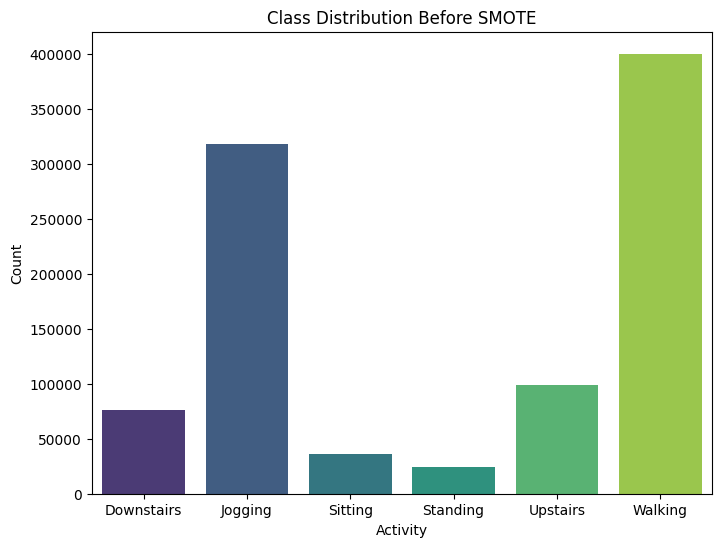

/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_33306/3986546733.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_bal, y=counts_bal, palette="viridis")


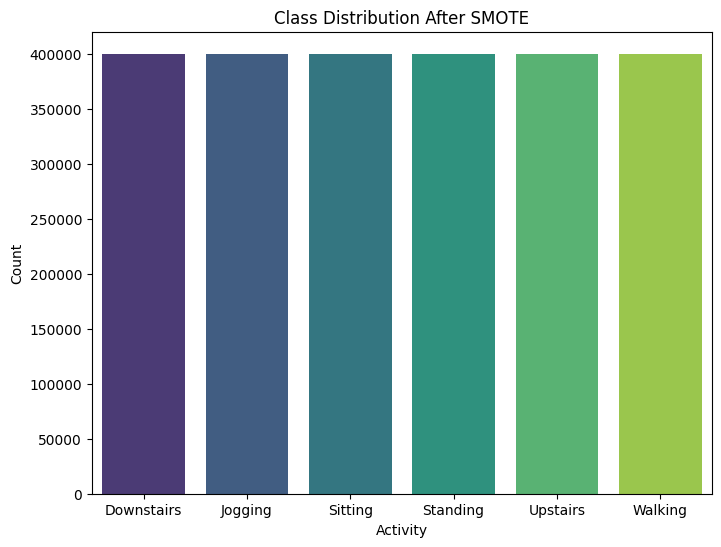

In [46]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# train_df: 기존 train 데이터프레임 (activity 라벨과 feature들이 포함된 상태)
# 예시: 
# train_df.head()
#   feature1  feature2  ... activity
# 0   ...      ...            Walking
# 1   ...      ...            Jogging
# ...

# 1. 라벨 인코딩 (문자열 -> 정수)
le = LabelEncoder()
y_train_encoded = le.fit_transform(train_df['activity'])
# 인코딩된 라벨에 대한 매핑 확인
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", mapping)

# 2. feature와 라벨 분리 (activity 컬럼 제외)
X_train_values = train_df.drop("activity", axis=1).values

# 3. Walking 라벨의 개수를 기준으로 타겟 수를 설정 (Walking이 최대 클래스로 가정)
walking_label_encoded = mapping['Walking']
majority_count = np.sum(y_train_encoded == walking_label_encoded)
print("Walking count:", majority_count)

# 4. 각 클래스별 현재 개수를 확인 후, Walking의 개수로 맞추기 위한 sampling_strategy 딕셔너리 생성
unique, counts = np.unique(y_train_encoded, return_counts=True)
sampling_strategy = {}
for cls, cnt in zip(unique, counts):
    if cls != walking_label_encoded:
        sampling_strategy[cls] = majority_count  # minority 클래스는 walking_count로 증강
print("Sampling Strategy:", sampling_strategy)

# 5. SMOTE 적용 (sampling_strategy를 딕셔너리 형태로 전달)
sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_values, y_train_encoded)

# 6. 증강된 라벨을 다시 원래의 문자열로 복원
y_train_balanced = le.inverse_transform(y_train_balanced)

# 7. 증강 후 각 클래스의 분포 확인
unique_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)
print("After SMOTE balancing:")
for label, count in zip(unique_bal, counts_bal):
    print(f"{label}: {count}")

# (선택사항) 증강된 데이터를 DataFrame으로 변환 (원래 feature 컬럼명을 그대로 사용)
train_df_balanced = pd.DataFrame(X_train_balanced, columns=train_df.drop("activity", axis=1).columns)
train_df_balanced["activity"] = y_train_balanced

# 8. 분포 시각화 (SMOTE 전후 비교)
import matplotlib.pyplot as plt
import seaborn as sns

# SMOTE 전 분포
unique_orig, counts_orig = np.unique(train_df['activity'], return_counts=True)
plt.figure(figsize=(8,6))
sns.barplot(x=unique_orig, y=counts_orig, palette="viridis")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

# SMOTE 후 분포
plt.figure(figsize=(8,6))
sns.barplot(x=unique_bal, y=counts_bal, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

In [47]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import OneHotEncoder  # CrossEntropyLoss는 정수형 라벨을 사용하므로 OneHot은 필요없음

#############################################
# 1. 데이터 전처리 및 레이블 인코딩
#############################################
# df는 이미 'x_axis', 'y_axis', 'z_axis', 'activity' 컬럼을 가진 DataFrame이라고 가정합니다.
le = LabelEncoder()
test_df['ActivityEncoded'] = le.fit_transform(test_df['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)
train_df_balanced['ActivityEncoded'] = le.fit_transform(train_df_balanced['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)

활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']
활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


In [48]:
test_df.activity.value_counts()

activity
Downstairs    24000
Jogging       24000
Sitting       24000
Standing      24000
Upstairs      24000
Walking       24000
Name: count, dtype: int64

In [49]:
def create_dataset(X, y, time_steps=1, step=1):
    """
    X: 센서 데이터가 담긴 DataFrame (예: ["x_axis", "y_axis", "z_axis"])
    y: 라벨(인코딩된 값)이 담긴 Series (예: df["ActivityEncoded"])
    time_steps: 각 시퀀스(윈도우)의 길이 (예: 200)
    step: 윈도우 생성 시 이동 간격 (예: 40)
    """
    Xs, ys = [], []
    for i in range(0, len(X) - time_steps, step):
        # i부터 i+time_steps까지의 센서 데이터를 numpy 배열로 변환
        v = X.iloc[i:(i + time_steps)].values
        # 해당 구간의 라벨들을 선택하고, 다수결(mode)로 대표 라벨 결정
        window_labels = y.iloc[i:(i + time_steps)]
        # Pandas의 mode()를 사용하여 최빈값 구하기
        mode_label = window_labels.mode()[0]
        Xs.append(v)
        ys.append(mode_label)
    return np.array(Xs), np.array(ys).reshape(-1, 1)

In [50]:
# 가정: train_df와 test_df는 이미 준비되어 있으며, 
#         각각 원시 센서 데이터와 ActivityEncoded 컬럼을 포함합니다.

# 예시로 사용할 시퀀스 길이와 이동 간격 설정
TIME_STEPS = 200  # 각 윈도우(시퀀스)의 길이
STEP = 40         # 윈도우 생성 시 이동 간격

#############################################
# 1. train_df로부터 시퀀스 데이터 생성
#############################################
X_train_seq, y_train_seq = create_dataset(
    train_df_balanced[["x_axis", "y_axis", "z_axis"]], 
    train_df_balanced["activity"],
    time_steps=TIME_STEPS, 
    step=STEP
)

#############################################
# 2. test_df로부터 시퀀스 데이터 생성
#############################################
X_test_seq, y_test_seq = create_dataset(
    test_df[["x_axis", "y_axis", "z_axis"]], 
    test_df["activity"],
    time_steps=TIME_STEPS, 
    step=STEP
)

#############################################
# 3. train 시퀀스 데이터에서 train/validation 분리
#############################################
# stratify 옵션을 사용하여 클래스 비율을 유지합니다.
from sklearn.model_selection import train_test_split

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq, y_train_seq, test_size=0.2, random_state=42, stratify=y_train_seq
)

print("Train shape:", X_train_seq.shape, y_train_seq.shape)
print("Validation shape:", X_val_seq.shape, y_val_seq.shape)
print("Test shape:", X_test_seq.shape, y_test_seq.shape)

Train shape: (48044, 200, 3) (48044, 1)
Validation shape: (12011, 200, 3) (12011, 1)
Test shape: (3595, 200, 3) (3595, 1)


In [51]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder를 통해 y 라벨을 정수형으로 변환하는 함수 예시
def encode_labels(y):
    le = LabelEncoder()
    return le, le.fit_transform(y.ravel())

# prepare_loader 함수 수정: encoder를 인자로 받아 변환된 라벨을 사용하거나, 없으면 새로 생성
def prepare_loader(X, y, batch_size=64, encoder=None):
    # X 텐서 생성: (batch, window_size, channels) → (batch, channels, window_size)
    X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
    
    # y가 이미 숫자가 아니라면, LabelEncoder를 사용하여 정수형으로 변환
    if encoder is None:
        le, y_encoded = encode_labels(y)
    else:
        y_encoded = encoder.transform(y.ravel())
    
    y_tensor = torch.tensor(y_encoded, dtype=torch.long).squeeze()
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader, (encoder if encoder is not None else le)

# 예시: train, validation, test 각각에 대해 prepare_loader 호출
# train_loader를 만들 때 encoder를 생성합니다.
train_loader, le = prepare_loader(X_train_seq, y_train_seq, batch_size=64)
# validation과 test는 동일한 encoder를 사용하여 변환합니다.
val_loader, _ = prepare_loader(X_val_seq, y_val_seq, batch_size=64, encoder=le)
test_loader, _ = prepare_loader(X_test_seq, y_test_seq, batch_size=64, encoder=le)

In [52]:

#############################################
# 5. 간단한 1D CNN 분류기 정의
#############################################
import torch.nn as nn
import torch.optim as optim

# Device 설정 (MPS, CUDA 또는 CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple GPU)")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, window_size=200):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * (window_size // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Using device: MPS (Apple GPU)


In [53]:
#############################################
# 6. 모델 학습 및 평가
#############################################
num_epochs = 10  # 학습 에폭 수
window_size=200
model = SimpleCNN(num_classes=num_classes, window_size=window_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n=== 모델 학습 시작 ===")
# 에폭별 손실과 정확도를 저장할 리스트
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == y_batch)
        total_train += y_batch.size(0)
    
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc.item())
    
    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    total_val = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_running_loss += loss.item() * X_val.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == y_val)
            total_val += y_val.size(0)
    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = val_running_corrects.float() / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")



=== 모델 학습 시작 ===
Epoch 1/10, Train Loss: 0.2971, Train Acc: 0.8883, Val Loss: 0.1687, Val Acc: 0.9400
Epoch 2/10, Train Loss: 0.1094, Train Acc: 0.9616, Val Loss: 0.0899, Val Acc: 0.9716
Epoch 3/10, Train Loss: 0.0650, Train Acc: 0.9777, Val Loss: 0.0904, Val Acc: 0.9698
Epoch 4/10, Train Loss: 0.0439, Train Acc: 0.9850, Val Loss: 0.0740, Val Acc: 0.9765
Epoch 5/10, Train Loss: 0.0341, Train Acc: 0.9884, Val Loss: 0.0631, Val Acc: 0.9821
Epoch 6/10, Train Loss: 0.0218, Train Acc: 0.9925, Val Loss: 0.0878, Val Acc: 0.9764
Epoch 7/10, Train Loss: 0.0199, Train Acc: 0.9932, Val Loss: 0.1020, Val Acc: 0.9738
Epoch 8/10, Train Loss: 0.0172, Train Acc: 0.9943, Val Loss: 0.0785, Val Acc: 0.9785
Epoch 9/10, Train Loss: 0.0189, Train Acc: 0.9938, Val Loss: 0.0781, Val Acc: 0.9786
Epoch 10/10, Train Loss: 0.0135, Train Acc: 0.9957, Val Loss: 0.0772, Val Acc: 0.9809


In [54]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze()  # 만약 y_batch가 (batch_size, 1)이라면
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"테스트 정확도: {accuracy:.2f}%")

테스트 정확도: 77.25%


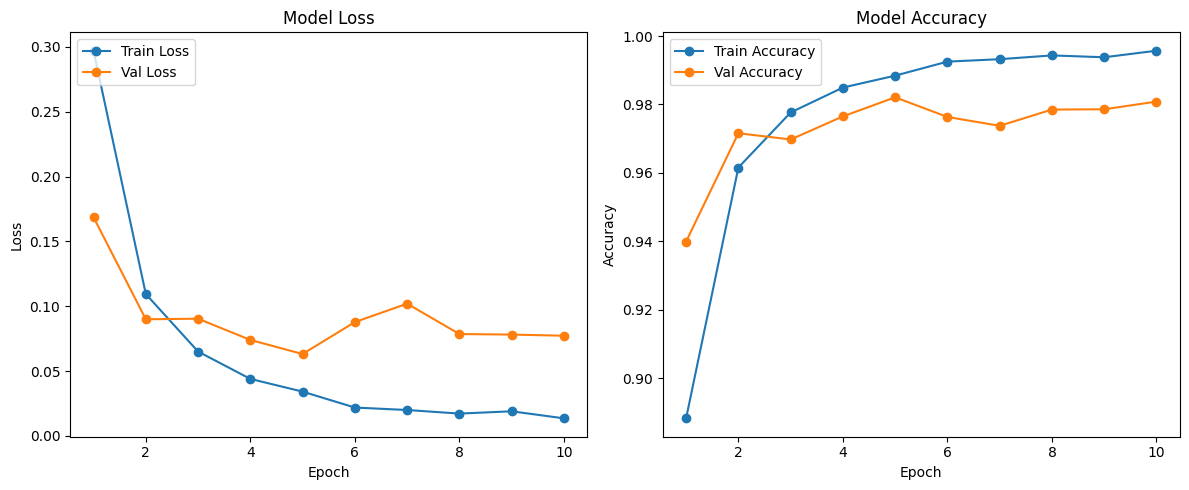

In [55]:
# 학습 및 검증 결과 플롯팅
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 손실 플롯
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# 정확도 플롯
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

F1 Score (weighted): 0.7734182445987611
Accuracy: 0.772461752433936
Classification Report:
              precision    recall  f1-score   support

     Walking       0.87      0.68      0.77       598
     Jogging       0.78      0.53      0.63       600
    Upstairs       0.92      1.00      0.96       600
  Downstairs       1.00      0.76      0.86       600
     Sitting       0.50      0.70      0.58       600
    Standing       0.74      0.97      0.84       597

    accuracy                           0.77      3595
   macro avg       0.80      0.77      0.77      3595
weighted avg       0.80      0.77      0.77      3595



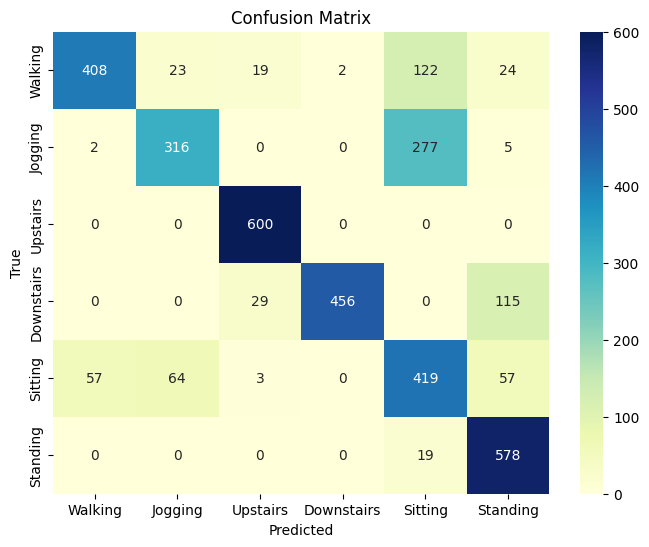

In [56]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# LABELS는 클래스 이름을 지정합니다.
LABELS = ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']

# 모델을 평가 모드로 전환
model.eval()

# 전체 test 데이터에 대해 예측값과 정답을 모읍니다.
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)
        # 각 샘플에 대해 가장 높은 확률을 가진 클래스 인덱스 선택
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

# 혼동 행렬 계산
cm = confusion_matrix(all_true, all_preds)

# 평가 지표 출력
print("F1 Score (weighted):", f1_score(all_true, all_preds, average='weighted'))
print("Accuracy:", accuracy_score(all_true, all_preds))
print("Classification Report:")
print(classification_report(all_true, all_preds, target_names=LABELS))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="YlGnBu", xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()